# ASTRAL Visualizations

In this notebook we provide the code for generating all the figures found in the paper [PAPER NAME](link). There are several tunable parameters you can adjust below if you would like to study the behavior of our bounds in different regimes. The main code is hidden away in the utility library located at `/usr/jovyan/bipartition_covers`, so see there if you would like more implementation details. 

In [2]:
# sys libraries
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Data-science libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# MSC Simulation libraries
import dendropy
from dendropy.simulate import treesim
from dendropy import Tree, TreeList
import random

# Set plotting style and working directories
sns.set_theme()
sns.set_style('whitegrid')

workdir = os.environ.get('WORKDIR')

# change to current working directory
os.chdir(workdir)

base_dir = Path(workdir)
figures_dir = base_dir / "figures"

print(f'Current work directory is {workdir}')

Current work directory is /usr/jovyan/bipartition_covers


## Calculating Coalescent Probabilities

Recall that the basis of all our bounds are the probabilities $g_{i,j}(T)$ which encode the probability $i$ lineages coalesce into exactly $j$ lineages in time $T$ under Kingman's coalescence. Here, $T$ is measured in coalescent units. Recall it has the explicit formula

$$g_{ij}(T) := \sum_{k=j}^i \frac{e^{-{k \choose 2}T} (2k-1)(-1)^{k-j}j_{(k-1)} i_{[k]}}{j!(k-j)!i_{(k)}}$$

Here $a_{(k)} = a(a+1) \cdot ... \cdot (a+k-1)$ and $a_{[k]} = a(a-1)\cdot ... \cdot (a-k+1)$ denote the rising and falling factorial respectively. Since it is the basis of all our bounds, we spend a moment to develop a decently efficient implementation for calculating it. Rather than recalculating the factorials at every step we want to calculate them iteratively to save some time and avoid potential integer overflows. Note that:

$$g_{ij}(T) = \sum_{k=j}^i \frac{e^{-{k \choose 2}T} (2k-1)(-1)^{k-j}}{j!} \cdot \frac{j_{(k-1)} i_{[k]}}{(k-j)!i_{(k)}}$$

The second term can be re-written as:

$$c_k := \frac{j_{(k-1)} i_{[k]}}{(k-j)!i_{(k)}} = \left(\prod_{m=1}^{k-j} \frac{1}{m}\right)\left(\prod_{m=0}^{k-2} (j+m)\right)\left(\prod_{m=0}^{k-1} \frac{i-m}{i+m}\right)$$

In particular:

$$\frac{c_{k+1}}{c_k} = \frac{k+j-1}{k-j+1} \cdot \frac{i-k}{i+k}$$

Thus we can calculate $c_j$ for the first term using the above formula, and iteratively update it to get future values of $c_k$. This is what the function `utility.coalescent_probabilities.g_ij` carries out below. 

##### Alternatives

There are several other feasible methods for calculating $g_{ij}$. For one, by conditioning on the first coalescent time we have access to the recursion:

$$g_{i, j}(T) = \int_0^T g_{i-1, j}(T-t) \cdot {i \choose 2} exp\left(- {i \choose 2} t\right) \; dt \qquad g_{i, i}(T) = exp\left(-{i \choose 2}T\right)$$

Hence if we wanted to calculate $g_{i, j}(T)$ we could discretize $[0,T]$ using say $N$ points and explicitly calculate $g_{i,i}(t)$ at each discretization point $t$. We could then use standard numerical integration techiniques to dynamically calculate the values of $g_{i,j}(T)$.  


In [3]:
from utility.coalescent_probabilities import g_ij

### Plotting $g_{ij}(T)$

Here, we start by plotting our function $g_{ij}(T)$. 

In [4]:
from utility.plotting import plot_multiple_T_values

Comparing different T values for j=1


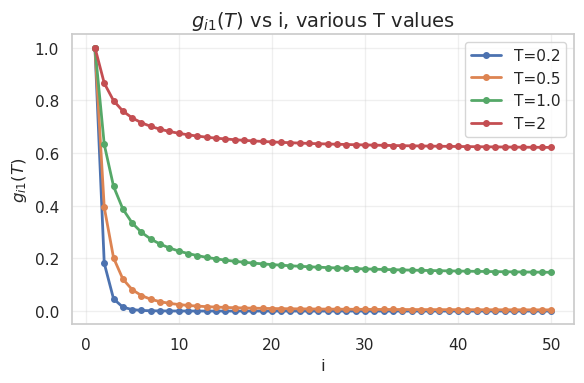

Plot saved to: /usr/jovyan/bipartition_covers/figures/g_i1_plot


In [5]:
j = 1
T_values = [0.2, 0.5, 1.0, 2]
print(f"Comparing different T values for j={j}")
plot_multiple_T_values(j, T_values, max_i=50, savepath=figures_dir / "g_i1_plot")

## Building Our Bounds

In the following sections we explore the various bounds we have developed throughout our work. 

In [6]:
from utility.bounds import original_bound, caterpillar_bound, one_step_bound, balanced_bound
from utility.plotting import plot_bound

In [7]:
T_vals = [0.1, 0.2, 0.5, 1, 2]
k_vals = range(5, 35, 5)
q = 0.99
log_plot=True
figsize=(12,4)

### Original Bound

The original paper produced a bound of the form:

$$n \geq \frac{\log\left(\frac{1-q}{k-3} \right)}{\log\left(1-g_{k-2,1}(T_{min}) \right)}$$

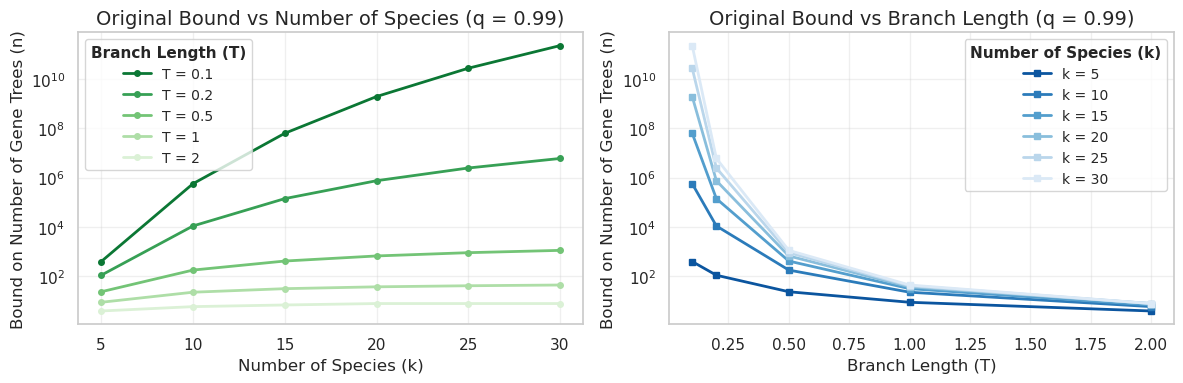

Plot saved to: /usr/jovyan/bipartition_covers/figures/bound_plots/original_bound.png


In [8]:
save_path = figures_dir / 'bound_plots' / 'original_bound.png'
bound_name = 'Original'
_ = plot_bound(original_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

### Improved Bound 1: Caterpillar Trees

Our first new bound is defined implicitly by:

$$n^* := \min\left\{ n \in \mathbb{N} : \sum_{\ell=2}^{k-2} (1 - g_{\ell,1}(T_{min}))^{n} \le 1-q \right\}$$

Any $n \ge n^*$ guarantees a bipartition cover with probability at least $q$.

This bound was developed by recognizing caterpillar trees maximize increasing sums.


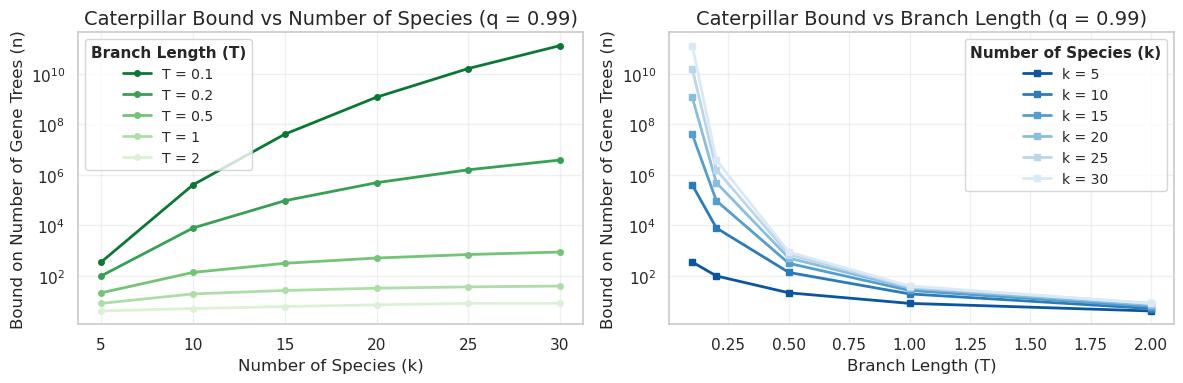

Plot saved to: /usr/jovyan/bipartition_covers/figures/bound_plots/caterpillar_bound.png


In [9]:
save_path = figures_dir / 'bound_plots' / 'caterpillar_bound.png'
bound_name = 'Caterpillar'
_ = plot_bound(caterpillar_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

### Improved Bound 2: Coalescents One-Step Down

By considering coalescent events occuring one-step below the current edge, we were able to improve the bound to:

$$ n^* := \min\left\{ n \in \mathbb{N} : \sum_{\ell = 2}^{k-2} (1-q_{\ell})^{n} \le 1-q \right\}$$

where for $m(\ell) := \lfloor \ell / 2\rfloor$ we define:

 $$ q_\ell := \sum_{r=1}^{m(\ell)} \sum_{s=1}^{\ell-m(\ell)} g_{m(\ell),r}(T_{min}) \cdot g_{\ell-m(\ell), s}(T_{min}) \cdot g_{r+s, 1}(T_{min})$$

Here $q_\ell$ is essentially just $\mathbb{E} g_{Z_{m(\ell)} + Z_{\ell - m(\ell)}, 1}(T_{min})$ is the probabilility that if we start with two subpopulations of size $m(\ell)$ and $\ell - m(\ell)$ respectively then we coalesce to a single lineage after two generations of length $T$. 


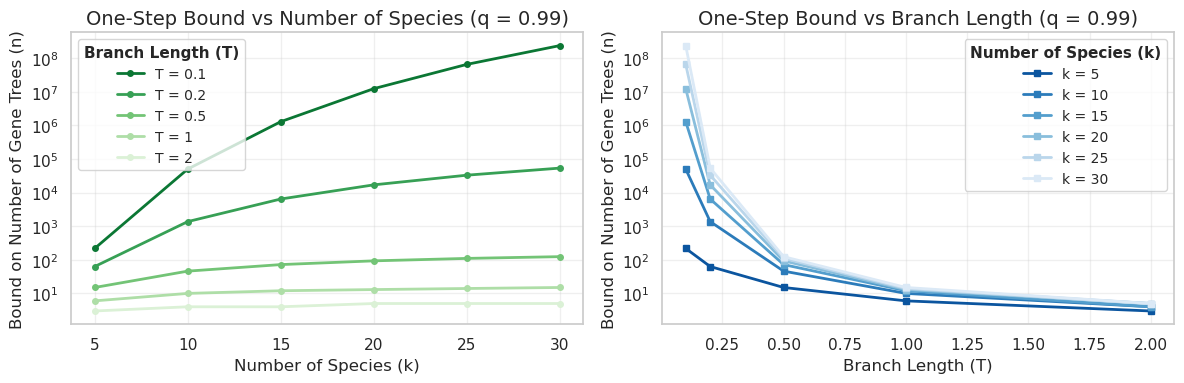

Plot saved to: /usr/jovyan/bipartition_covers/figures/bound_plots/one_step_bound.png


In [10]:
save_path = figures_dir / 'bound_plots' / 'one_step_bound.png'
bound_name = 'One-Step'
_ = plot_bound(one_step_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

### Improved Bound 3: Balanced Trees

We could further improve our one-step bound by taking into account coalescent events that occur deeper down in the tree, rather than just those occuring in the immediate children of the current branch. Doing so gave us a new bound:

$$n^* := \min\left\{ n \in \mathbb{N} : \sum_{\ell = 2}^{k-2} (1-z_{\ell})^{n} \le 1-q \right\}$$

where $z_\ell := \mathbb{P}(Z_{\ell} = 1)$ and where the distributions of $Z_\ell$ are defined recursively as:

$$\mathbb{P}(Z_\ell = j) = g_{Z_{\lceil \ell/2\rceil} + Z_{\lfloor \ell/2\rfloor}', j} (T_{min}) \qquad Z_1 \equiv 1$$

|Here $Z_i'$ is an iid copy of $Z_i$ and $T_{min}$ is the minimum branch length (in coalescent units) in the species tree.


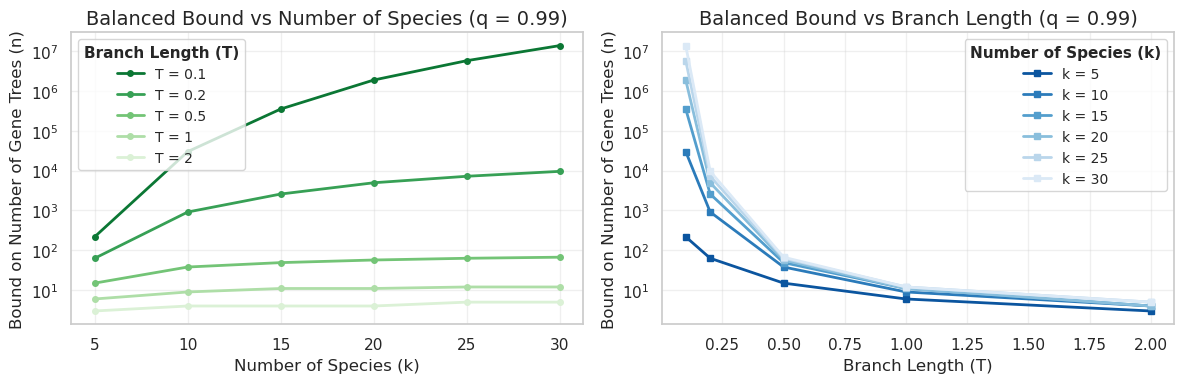

Plot saved to: /usr/jovyan/bipartition_covers/figures/bound_plots/balanced_bound.png


In [11]:
save_path = figures_dir / 'bound_plots' / 'balanced_bound.png'
bound_name = 'Balanced'
_ = plot_bound(balanced_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

## Improvement Ratios

In the following section, we compare the relative performances of our bounds.

In [12]:
from utility.plotting import plot_improvement_ratio

In [13]:
T_vals = [0.1, 0.2, 0.5, 1]
k_vals = range(5, 35, 5)
q = 0.95
log_plot=True
figsize=(12,4)

### New bounds Versus Old Bounds

##### Caterpillar Bound vs Original

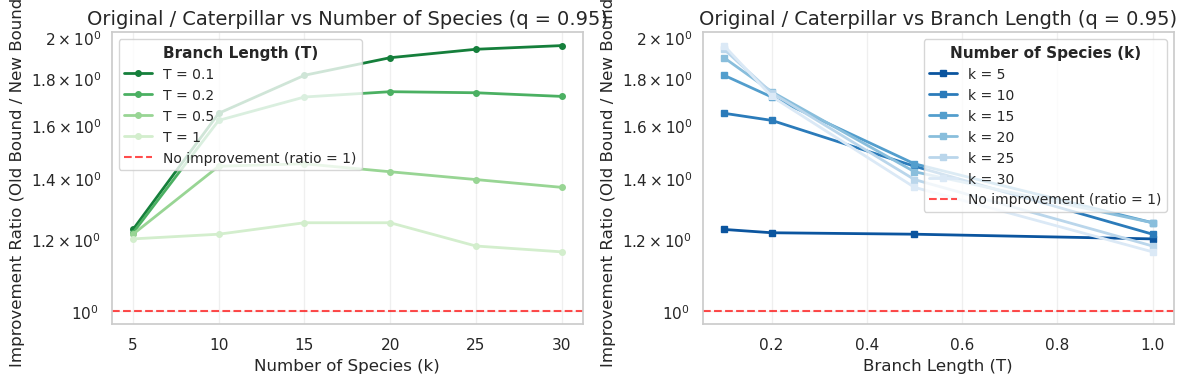

Plot saved to: /usr/jovyan/bipartition_covers/figures/improvement_ratios/cat_vs_original.png


In [14]:
save_path = figures_dir / 'improvement_ratios' / 'cat_vs_original.png'
old_name = 'Original'
new_name = 'Caterpillar'
plot_improvement_ratio(original_bound, caterpillar_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

##### One-Step Bound vs Original

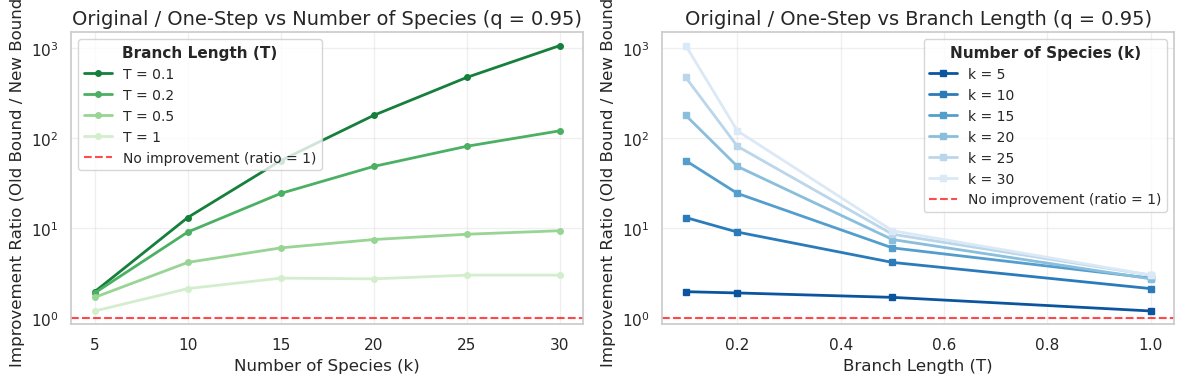

Plot saved to: /usr/jovyan/bipartition_covers/figures/improvement_ratios/onestep_vs_original.png


In [15]:
save_path = figures_dir / 'improvement_ratios' / 'onestep_vs_original.png'
old_name = 'Original'
new_name = 'One-Step'
plot_improvement_ratio(original_bound, one_step_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

##### Balanced vs Original

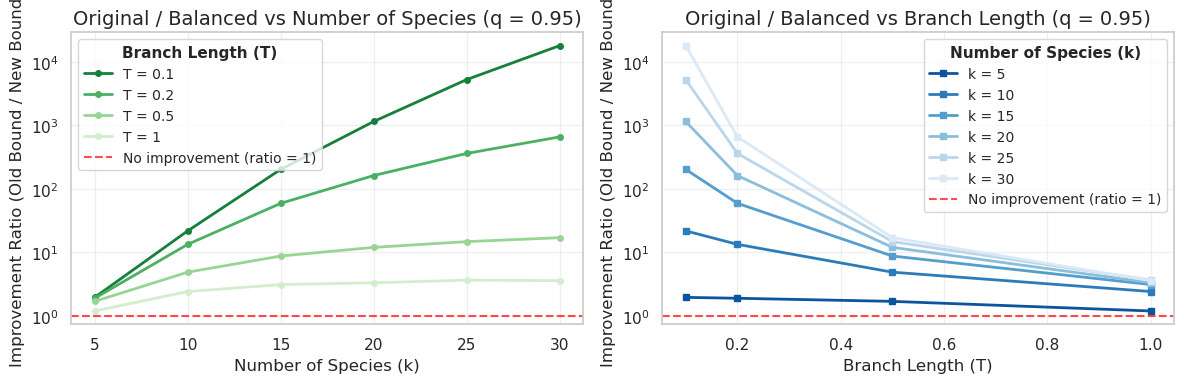

Plot saved to: /usr/jovyan/bipartition_covers/figures/improvement_ratios/balanced_vs_original.png


In [16]:
save_path = figures_dir / 'improvement_ratios' / 'balanced_vs_original.png'
old_name = 'Original'
new_name = 'Balanced'
plot_improvement_ratio(original_bound, balanced_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize,  savepath=save_path, old_name=old_name, new_name=new_name)

### New Versus New

##### Caterpillar vs One-Step

Theoretically the one-step bound should be no larger than the caterpillar bound, but let's check to what level it makes an actual improvement over the caterpillar bound. 

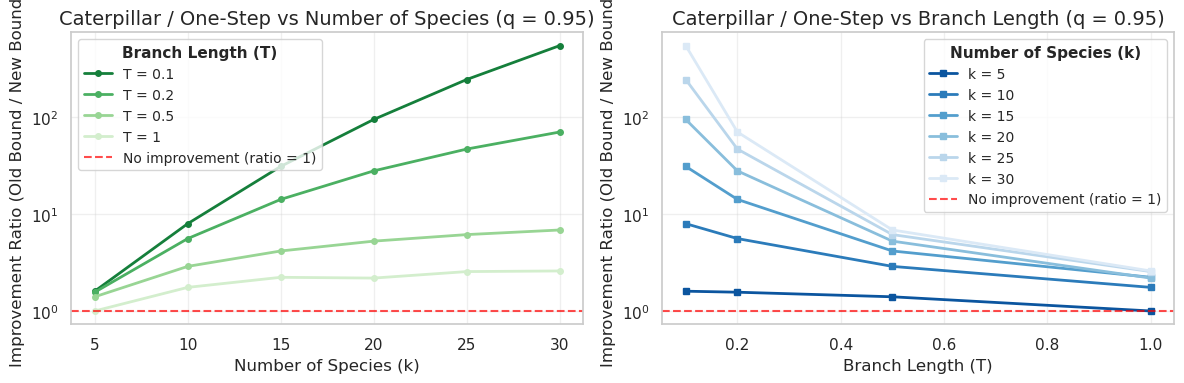

Plot saved to: /usr/jovyan/bipartition_covers/figures/improvement_ratios/one_step_vs_caterpillar.png


In [17]:
save_path = figures_dir / 'improvement_ratios' / 'one_step_vs_caterpillar.png'
old_name = 'Caterpillar'
new_name = 'One-Step'
plot_improvement_ratio(caterpillar_bound, one_step_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

##### Balanced vs One-Step

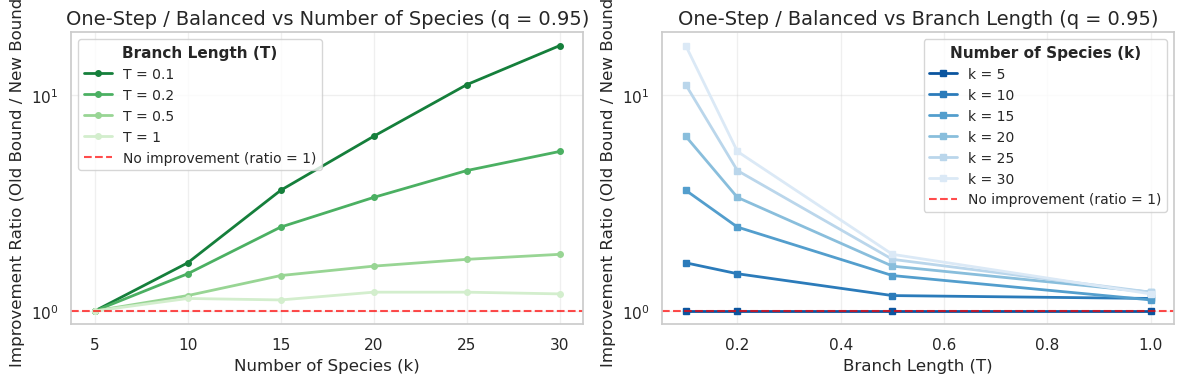

Plot saved to: /usr/jovyan/bipartition_covers/figures/improvement_ratios/balanced_vs_one_step.png


In [18]:
save_path = figures_dir / 'improvement_ratios' / 'balanced_vs_one_step.png'
old_name = 'One-Step'
new_name = 'Balanced'
plot_improvement_ratio(one_step_bound, balanced_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

## Gene Tree Simulations

Now we want to explore the empirical behavior of a variety of species tree topologies under the multispecies coalescent model (MSC). Namely, for a given species tree topology, how many gene trees are typically required until we get a bipartition cover of the species tree in practice. To measure this empirically, for a given trial we sample gene trees and collect their bipartitions until a bipartition cover of the species tree is obtained. We repeat this for many trials to get an estimate of quantiles of this bipartition cover distribution. We then compare these empirical results to the bounds we developed above to get a sense of how loose those bounds still are.

For this, we utilize the [Dendropy](https://jeetsukumaran.github.io/DendroPy/primer/dataobjects.html) phylogenetic package. In particular, the [Contained Coalescent](https://jeetsukumaran.github.io/DendroPy/primer/treesims.html#multispecies-coalescent-contained-coalescent-or-censored-coalescent-trees) allows us to simulate gene trees under the MSC model. 

Another candidate is [SimPhy](https://pmc.ncbi.nlm.nih.gov/articles/PMC4748750/) which may be useful for larger simulations. But for our purposes, Dendropy suffices.

Below we study a few different topologies. First, we analyze the "worst-case" topologies we identified in our paper: caterpillar trees and balanced trees. Under these topologies we expect our bounds to be reasonably close to tight since the descendant counts and coalescent probabilities of these topologies are directly used in our bounds. Then we study more of an average case by generating Yule trees. By exploring the distribution of these overestimation ratios as we sample many species trees from the Yule model, we can get a better since of the typical amount our bound overestimates.

In [19]:
T_vals = [0.1, 0.2, 0.5, 1]
k_vals = [10, 15, 20, 25, 30]

num_samples = 10000
max_genes = 100000
q = 0.9
tol = 0.01

# Set seed for DendroPy's random number generator (for reproducibility)
random_seed = 42
rng = random.Random(random_seed)

##### Tree generation and Sampling

Here we include some code for generating samples from the MSC model under a given species tree topology, and for estimating the bipartition coverage probabilities.

In [20]:
from utility.build_tree_topologies import create_caterpillar_tree, create_balanced_tree, create_yule_tree
from utility.plotting import make_all_overestimation_plots
from utility.msc_sampling import get_T_min

In [21]:
all_bounds = [original_bound, caterpillar_bound, balanced_bound]
names = ['Original', 'Caterpillar', 'Balanced']

### Caterpillar and Balanced Trees

We saw in our paper's analysis that balanced trees and caterpillar trees, where all the branch lengths were equal to $T_{min}$, were in some sense the worst-case when it comes to our bounds. Hence, these are the trees we expect our bounds to be the most tight on.  

##### Caterpillar Tree

In [22]:
num_species = 8
T_min = 1

c_tree = create_caterpillar_tree(num_species, T_min)
print(f'Caterpillar tree (T_min = {get_T_min(c_tree)})')
c_tree.print_plot()

Caterpillar tree (T_min = 1.0)
                                                                 /---------- T0
                                                      /----------+             
                                           /----------+          \---------- T1
                                           |          |                        
                                /----------+          \--------------------- T2
                                |          |                                   
                     /----------+          \-------------------------------- T3
                     |          |                                              
          /----------+          \------------------------------------------- T4
          |          |                                                         
/---------+          \------------------------------------------------------ T5
|         |                                                                    
+        

T_min=1, k=30: 100%|██████████| 20/20 [32:38<00:00, 97.94s/it]    

################################################################################
Results for Original bound
################################################################################


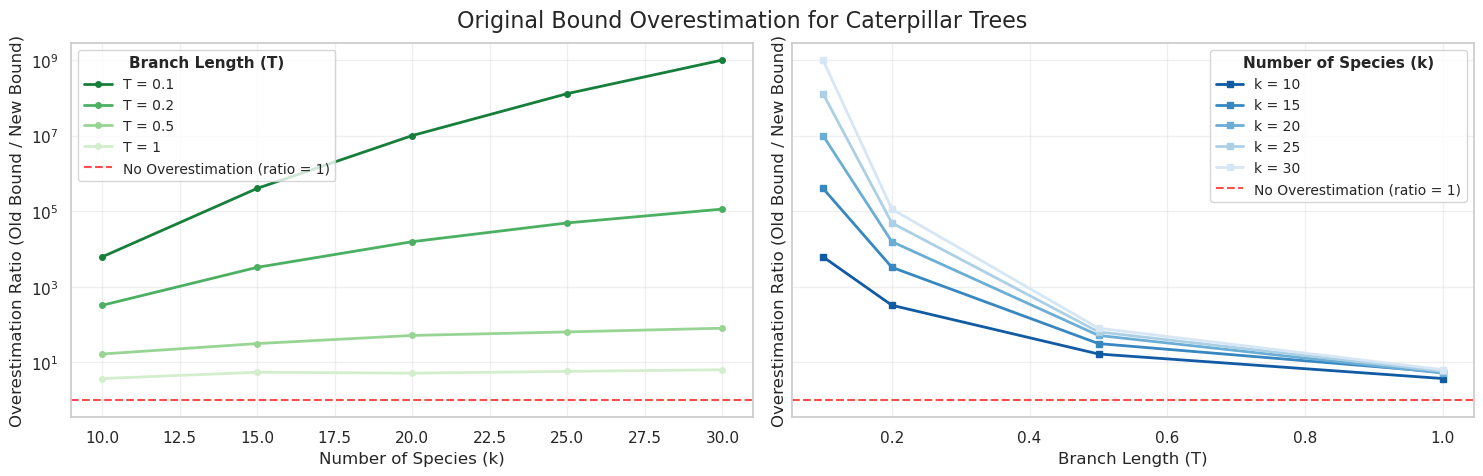

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_original_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_original_bound_vs_q.png


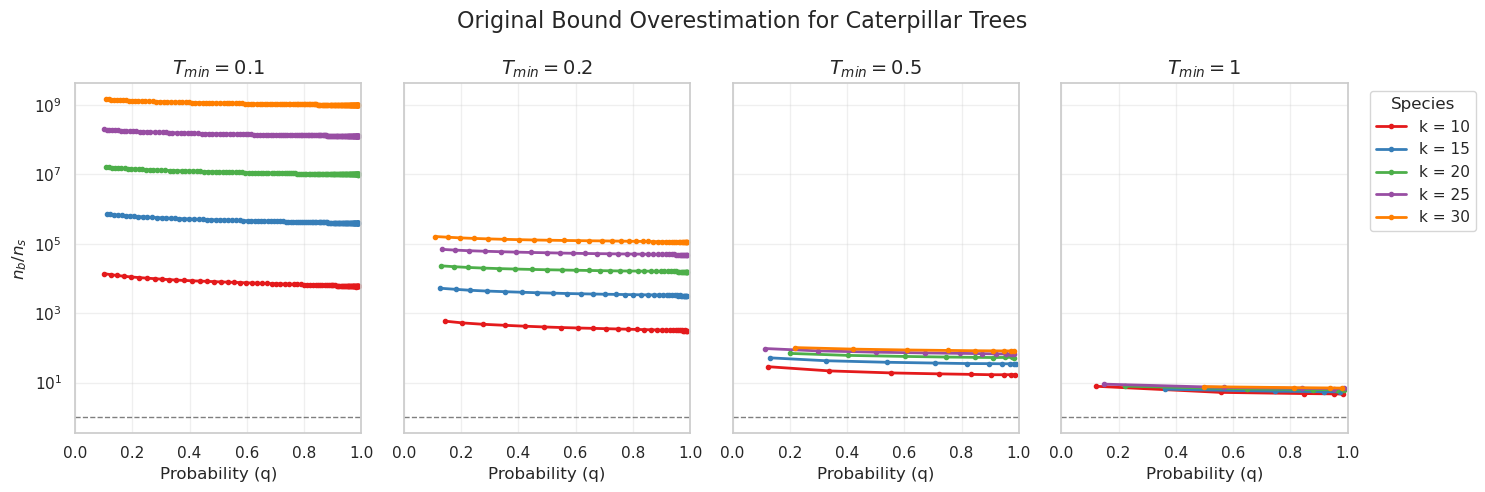

################################################################################
Results for Caterpillar bound
################################################################################


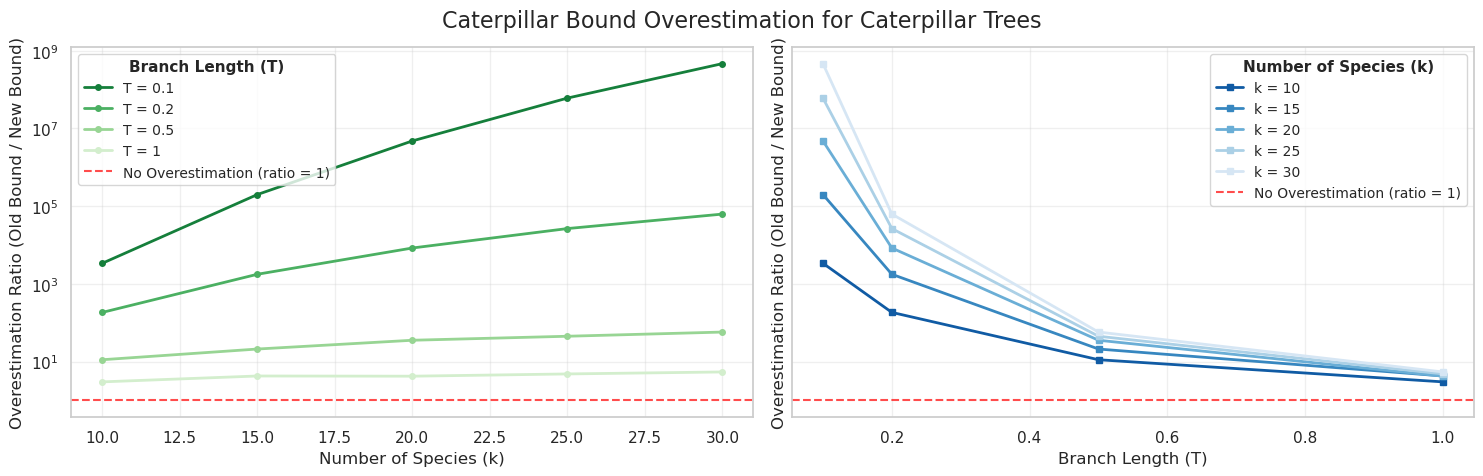

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_caterpillar_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_caterpillar_bound_vs_q.png


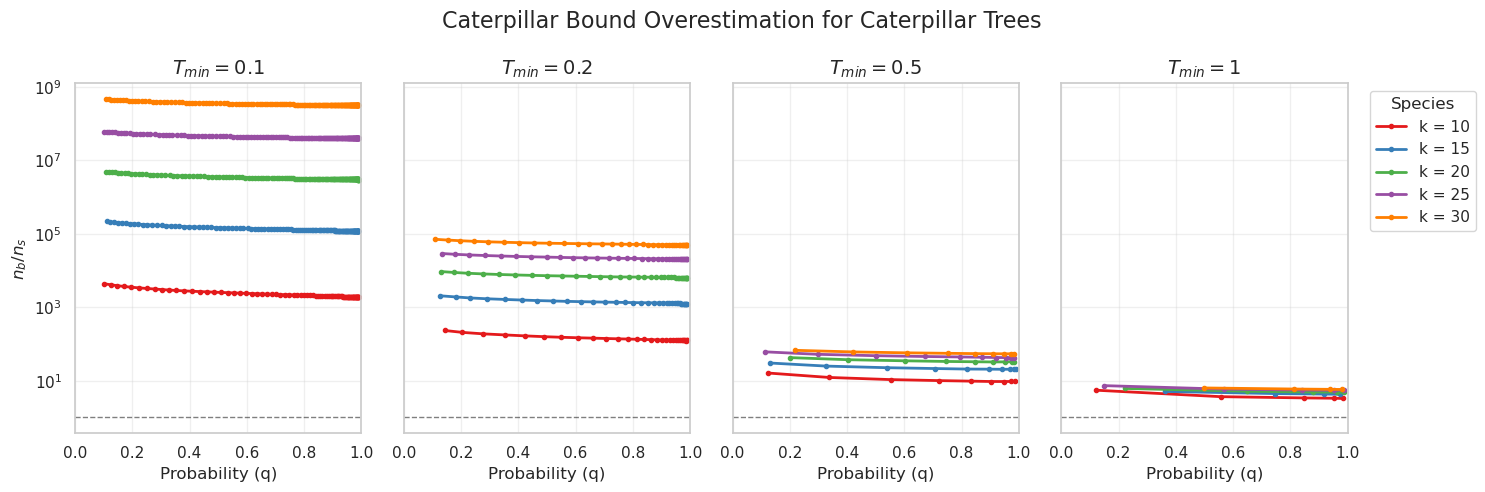

################################################################################
Results for Balanced bound
################################################################################


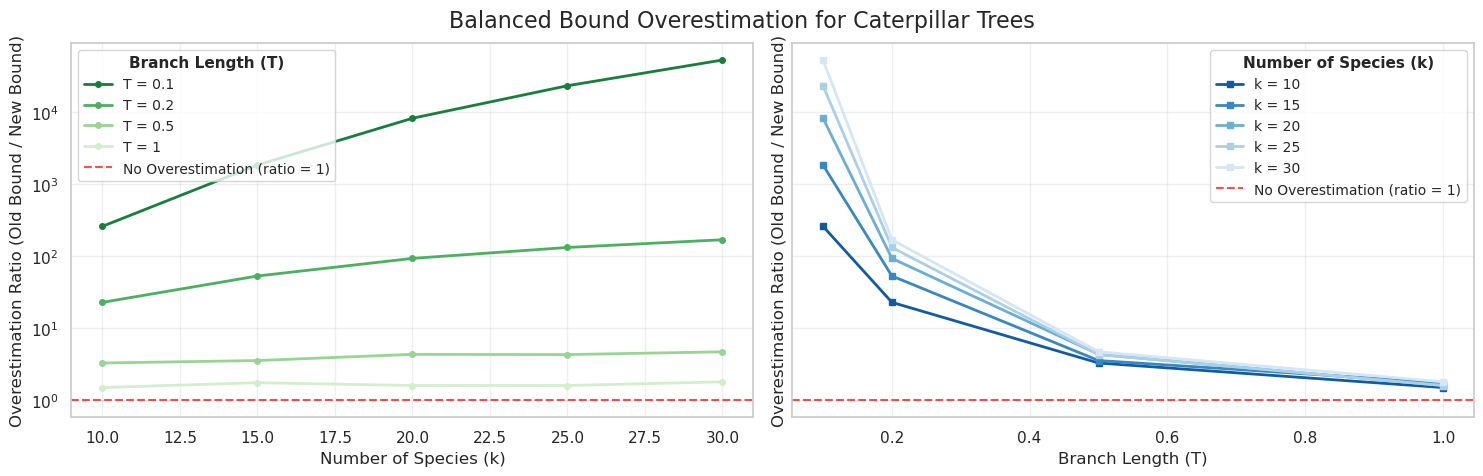

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_balanced_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_balanced_bound_vs_q.png


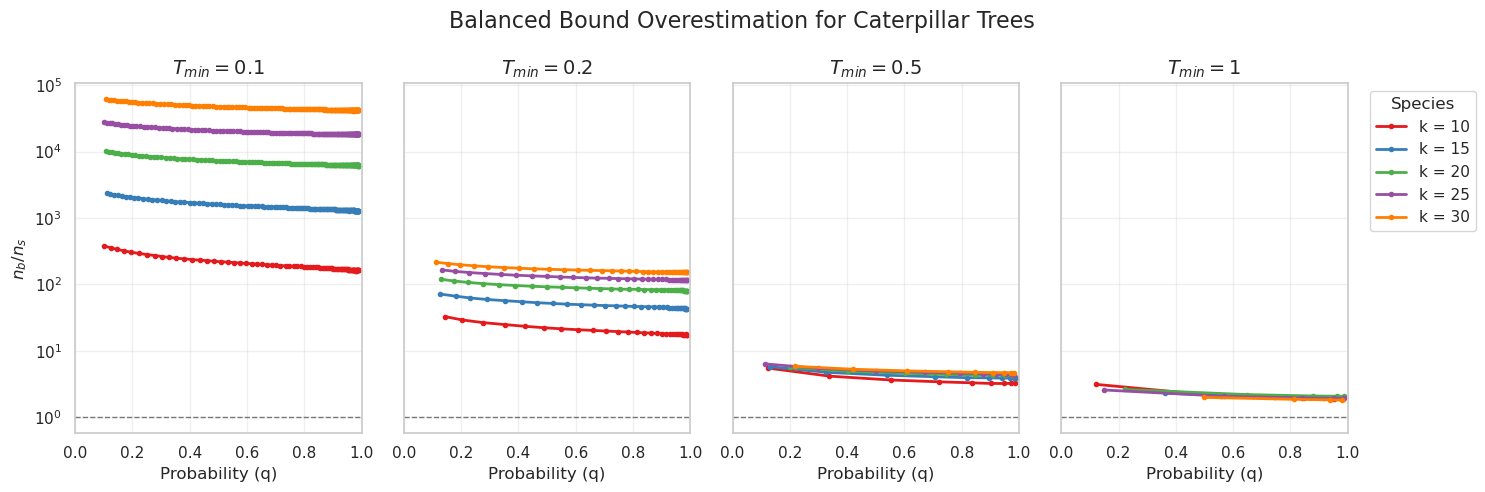

In [23]:
tree_name = 'Caterpillar'
species_tree_generator = create_caterpillar_tree
make_all_overestimation_plots(species_tree_generator, tree_name, 
                              k_vals, T_vals, q, 
                              all_bounds, names,
                              num_samples=num_samples, max_genes=max_genes, 
                              tolerance=tol,
                              rng=rng)

##### Balanced Tree

In [24]:
bal_tree = create_balanced_tree(num_species, T_min)
print('Balanced Tree')
bal_tree.print_plot()

Balanced Tree
                                                  /------------------------- T0
                         /------------------------+                            
                         |                        \------------------------- T1
/------------------------+                                                     
|                        |                        /------------------------- T2
|                        \------------------------+                            
|                                                 \------------------------- T3
+                                                                              
|                                                 /------------------------- T4
|                        /------------------------+                            
|                        |                        \------------------------- T5
\------------------------+                                                     
                         |

T_min=1, k=30: 100%|██████████| 20/20 [27:13<00:00, 81.67s/it]    

################################################################################
Results for Original bound
################################################################################


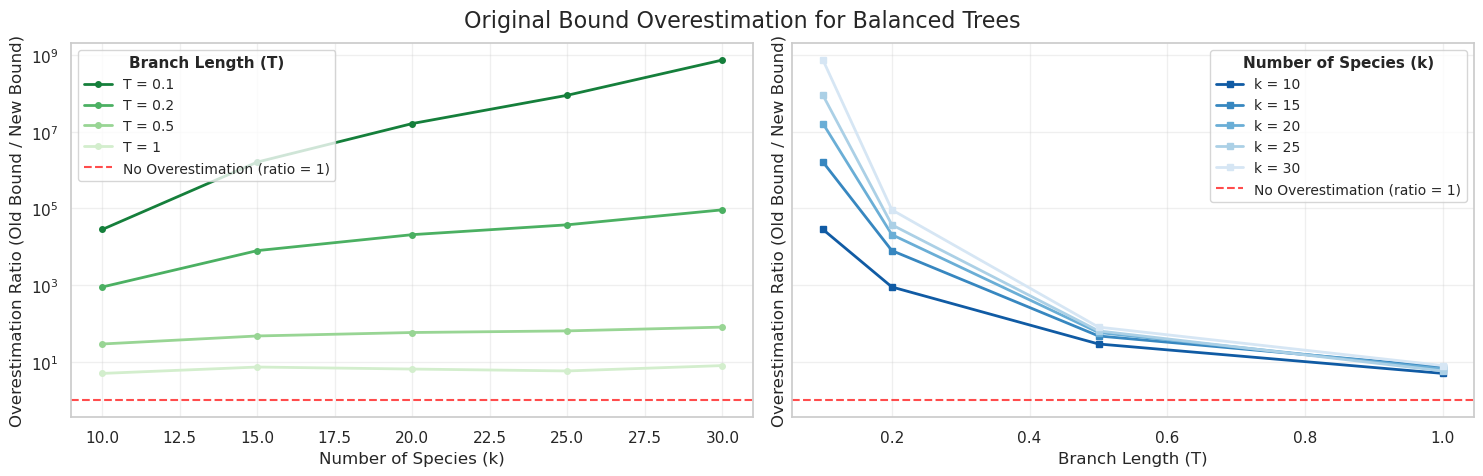

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_original_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_original_bound_vs_q.png


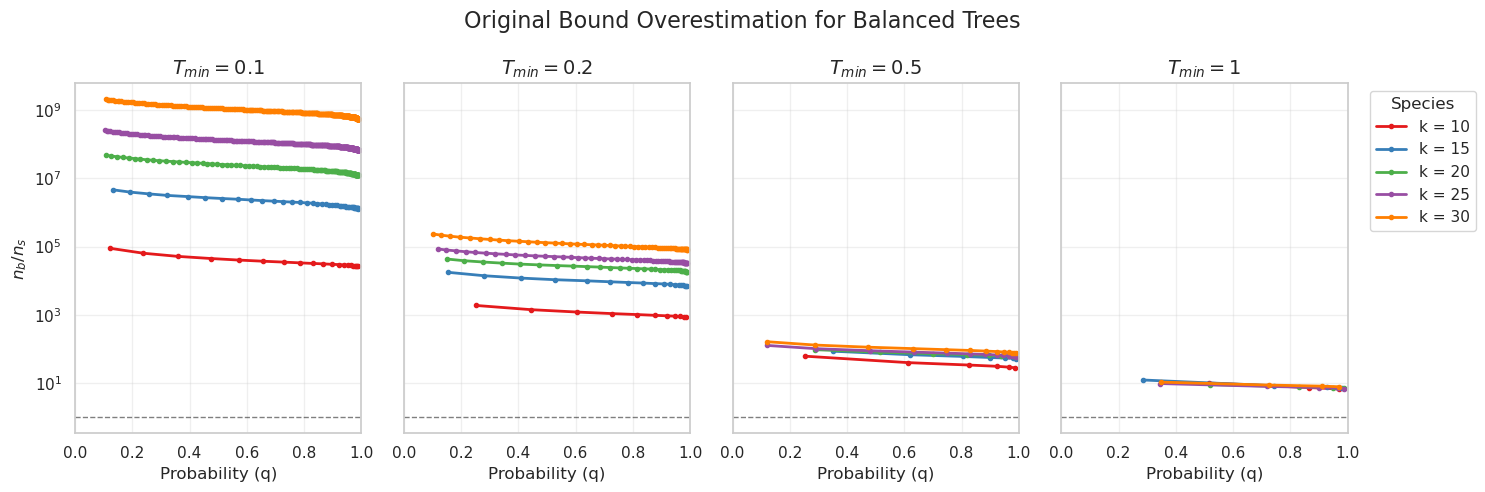

################################################################################
Results for Caterpillar bound
################################################################################


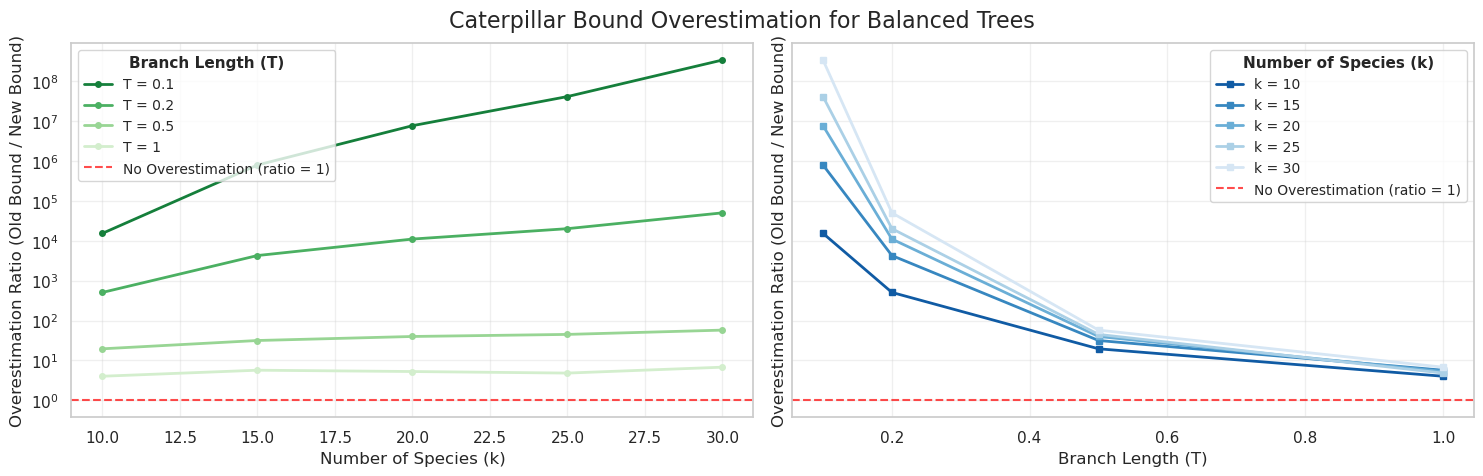

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_caterpillar_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_caterpillar_bound_vs_q.png


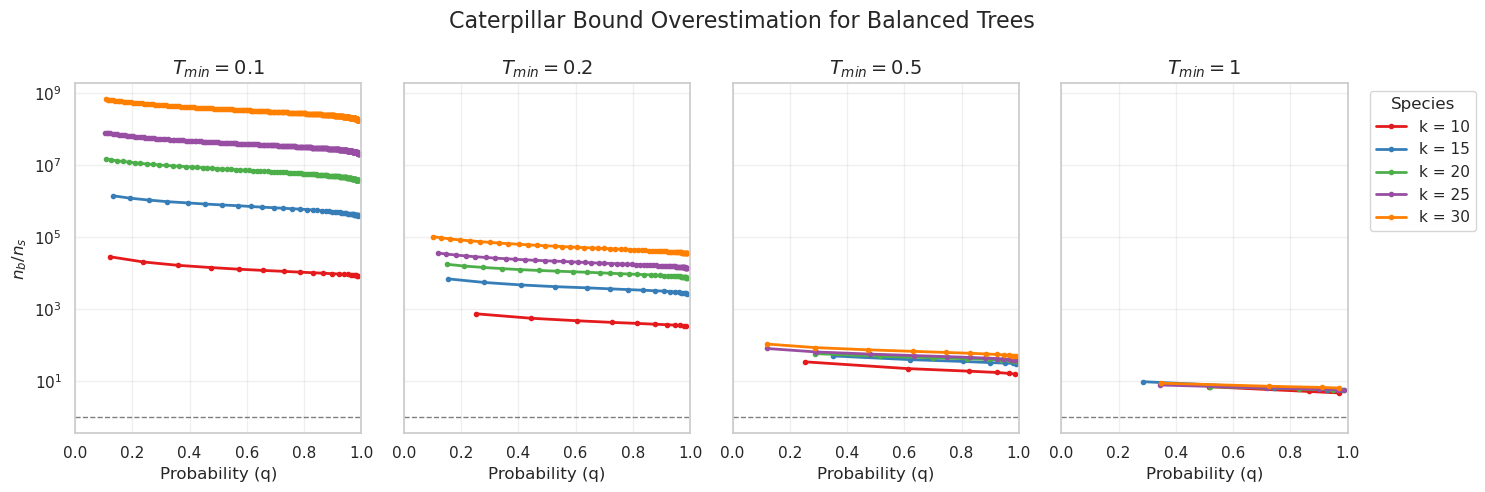

################################################################################
Results for Balanced bound
################################################################################


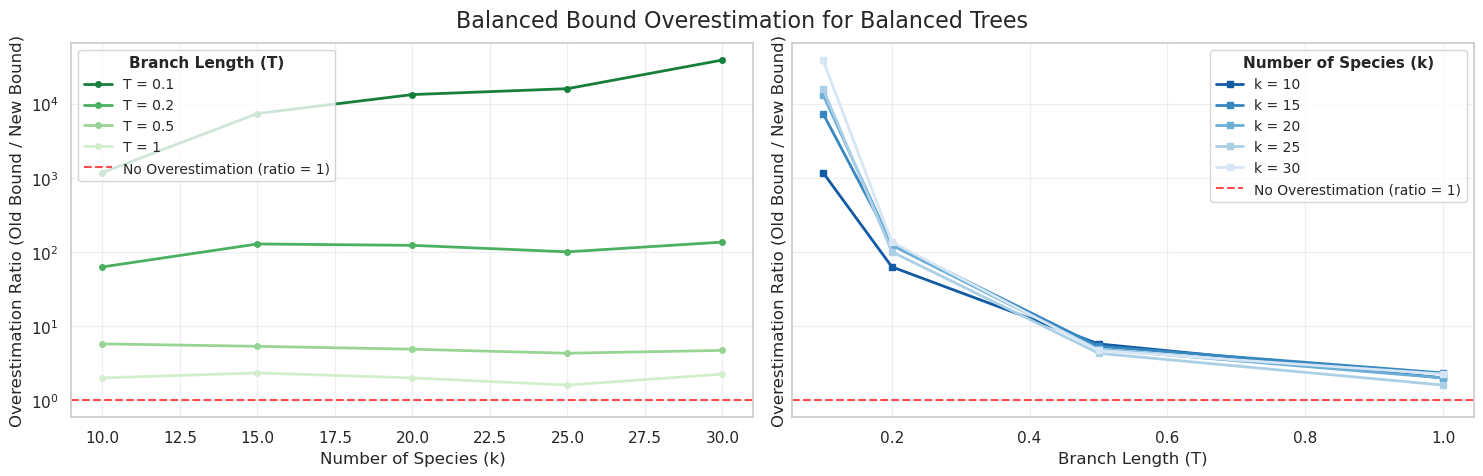

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_balanced_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_balanced_bound_vs_q.png


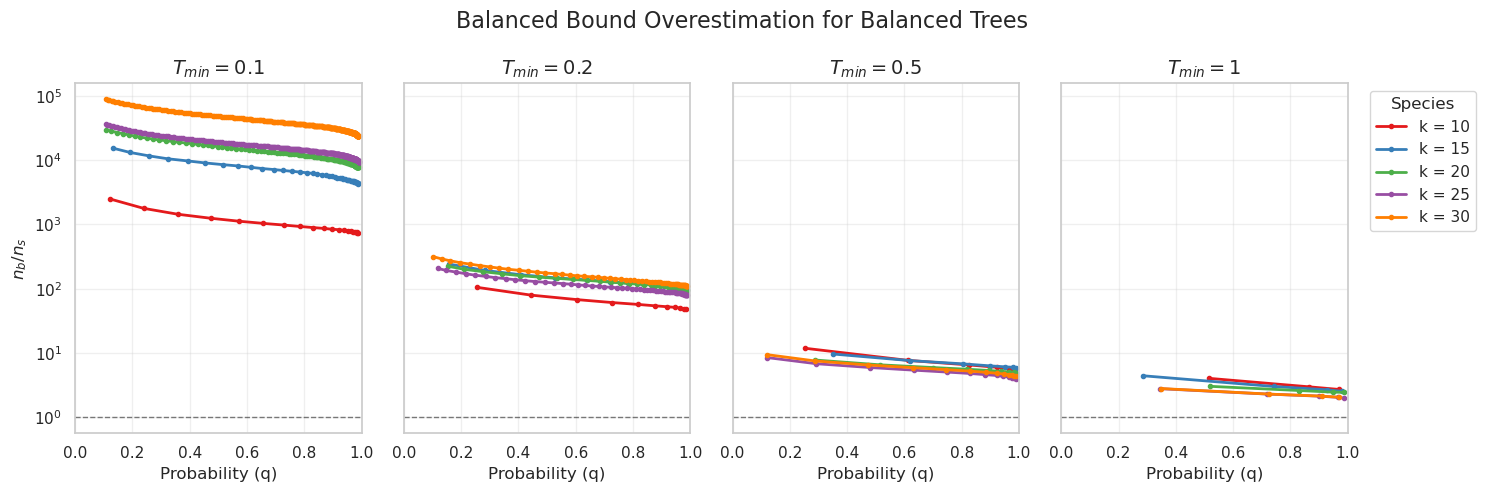

In [25]:
tree_name = 'Balanced'
species_tree_generator = create_balanced_tree
make_all_overestimation_plots(species_tree_generator, tree_name, 
                              k_vals, T_vals, q, 
                              all_bounds, names,
                              num_samples=num_samples, max_genes=max_genes, 
                              tolerance=tol,
                              rng=rng)


### Yule Trees

The Yule model is a simple birth-death process (with no death; e.g. a pure birth process). To generate a species tree under the Yule model, we start with a single population. Then, each existing population splits in two at rate $\lambda$ where the parameter $\lambda$ represents the birth-rate. This continues until the desired number of species/populations/leaves are produced. A Yule tree in a sense represents more of a "typical" evolutionary tree we would expect.

It is easy to see that each internal branch in such a tree then has that is length $\exp(2\lambda)$. We can then normalize all the branch lengths so that we have the desired minimum branch length $T_{min}$. Unlike our previous models, this allows for species trees that have non-constant branch lengths. Below we explore what the typical performance our new bounds achieve under this simple model. 

First, let's look at a single realization of such a tree. As we can see below, these trees tend to be fairly balanced by nature. 

In [26]:
birth_rate = 1
num_species = 20

# Generate species tree under Yule (birth-death) process
yule_tree = treesim.birth_death_tree(
    birth_rate=birth_rate, 
    death_rate=0.0, 
    num_extant_tips=num_species
)

# Find minimal length internal branch (exclude terminal/leaf branches)
T_min = get_T_min(yule_tree)
print('Minimal branch length: ', T_min) 

if num_species <= 20:
    yule_tree.print_plot()

Minimal branch length:  0.006019911930354514
                                                                /---------- T12
                                                     /----------+              
          /------------------------------------------+          \---------- T15
          |                                          |                         
          |                                          \--------------------- T10
          |                                                                    
          |                                                     /---------- T13
/---------+          /------------------------------------------+              
|         |          |                                          \---------- T3 
|         |          |                                                         
|         |          |                                          /---------- T19
|         |          |                               /----------+          

For a Yule tree we want to get a sense of what the "typical" overestimation error looks like. To do so, we generate many Yule trees and plot the distribution of their overestimation ratios. As before, we do this for a range of different values of the minimum branch length and species count, parameters $T_{min}$ and $k$ respectively.

In [27]:
import importlib, utility
from utility.plotting import plot_overestimation_distribution

importlib.reload(utility.plotting)

<module 'utility.plotting' from '/usr/jovyan/bipartition_covers/utility/plotting.py'>

Saving figure to /usr/jovyan/bipartition_covers/figures/overestimation_ratios/yule_trees_overestimation


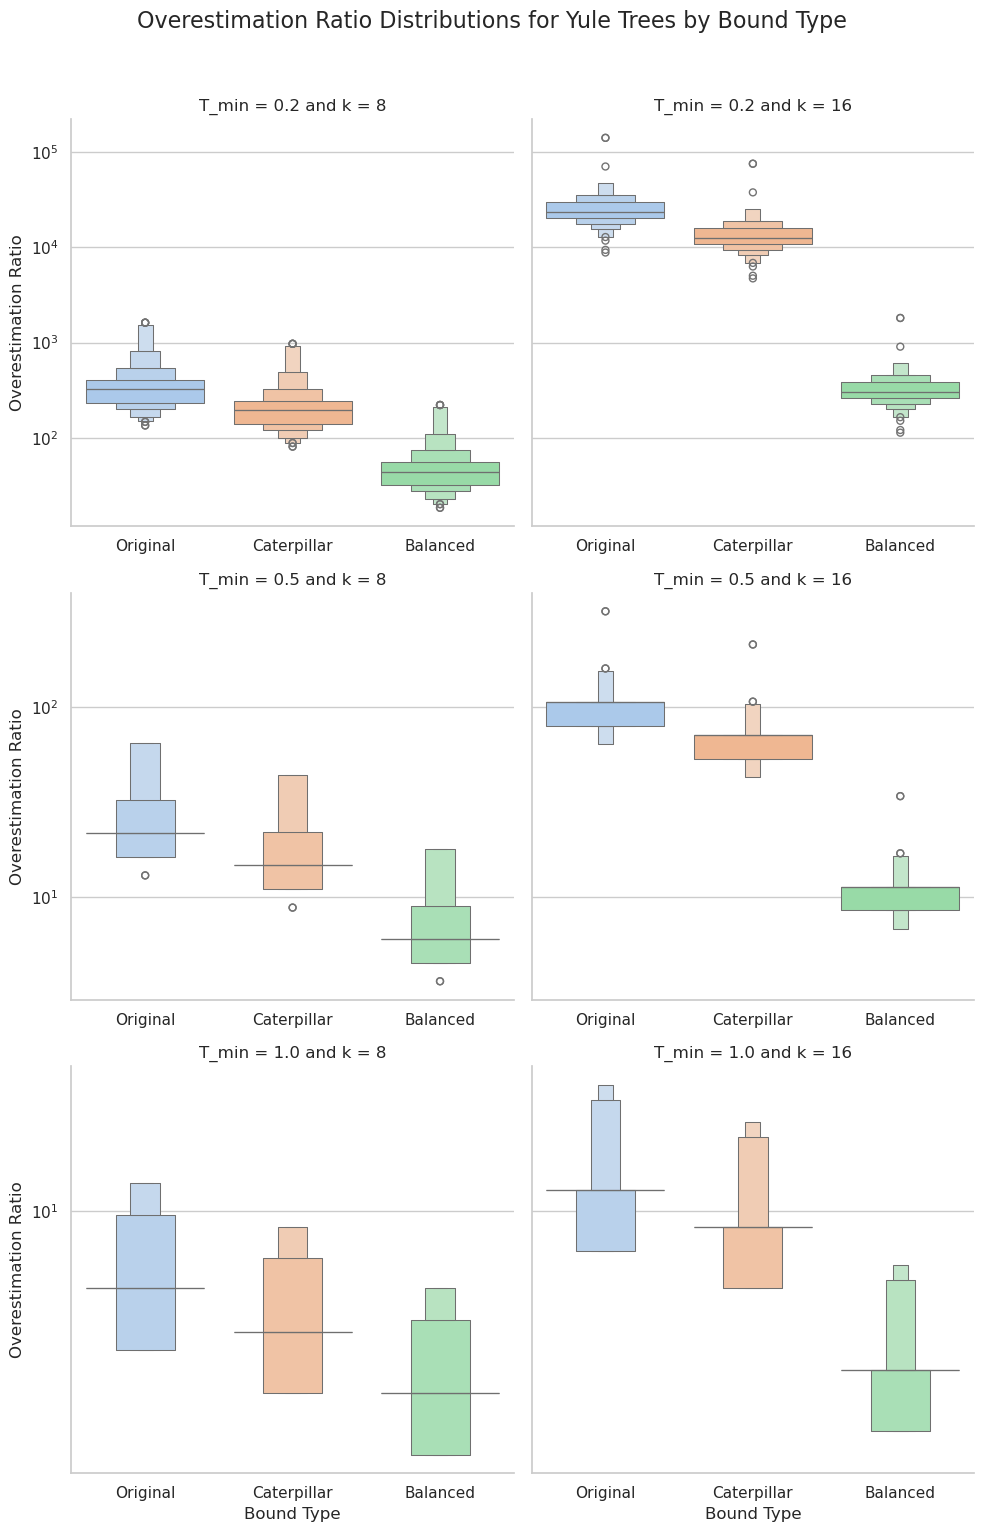

In [28]:
T_vals = [0.2, 0.5, 1]
k_vals = [8, 16]
birth_rate = 1
num_trees = 100
num_sample = 10000
max_genes = 100000

result = plot_overestimation_distribution(T_vals, k_vals, q, 
                                 all_bounds, names,
                                 num_trees=num_trees, num_samples=num_samples, max_genes=max_genes, 
                                 birth_rate=birth_rate,
                                 rng=rng)


In [33]:
print(result.shape)
result.head()

(1800, 6)


,k,T_min,bound_name,theoretical,empirical,overestimation_ratio
0,8,0.2,Original,1617.0,5.0,323.4
1,8,0.2,Caterpillar,970.0,5.0,194.0
2,8,0.2,Balanced,221.0,5.0,44.2
3,8,0.2,Original,1617.0,5.0,323.4
4,8,0.2,Caterpillar,970.0,5.0,194.0


In [34]:
display(result.groupby(['T_min', 'k', 'bound_name'])['overestimation_ratio'].describe())

count          mean           std          min  \
T_min k  bound_name                                                    
0.2   8  Balanced     100.0     53.349735     39.847333    18.416667   
         Caterpillar  100.0    234.159470    174.895536    80.833333   
         Original     100.0    390.346250    291.552661   134.750000   
      16 Balanced     100.0    365.035731    235.520788   113.187500   
         Caterpillar  100.0  15204.111080   9809.681400  4714.375000   
         Original     100.0  28414.131336  18332.776852  8810.437500   
0.5   8  Balanced     100.0      6.925065      3.516531     3.600000   
         Caterpillar  100.0     16.927935      8.595965     8.800000   
         Original     100.0     25.007177     12.698584    13.000000   
      16 Balanced     100.0     10.749667      3.800424     6.800000   
         Caterpillar  100.0     67.659667     23.920314    42.800000   
         Original     100.0    101.173333     35.768694    64.000000   
1.0   8  Balanced     100.0      3.180000      1.166710     2.000000   
         Caterpillar  100.0      4.770000      1.750065     3.000000   
         Original     100.0      6.360000      2.333420     4.000000   
      16 Balanced     100.0      3.570000      1.033170     2.333333   
         Caterpillar  100.0      9.180000      2.656724     6.000000   
         Original     100.0     11.730000      3.394703     7.666667   

                               25%           50%           75%       max  
T_min k  bound_name                                                       
0.2   8  Balanced        31.571429     44.200000     55.250000     221.0  
         Caterpillar    138.571429    194.000000    242.500000     970.0  
         Original       231.000000    323.400000    404.250000    1617.0  
      16 Balanced       258.714286    301.833333    384.837500    1811.0  
         Caterpillar  10775.714286  12571.666667  16028.875000   75430.0  
         Original     20138.142857  23494.500000  29955.487500  140967.0  
0.5   8  Balanced         6.000000      6.000000      6.000000      18.0  
         Caterpillar     14.666667     14.666667     14.666667      44.0  
         Original        21.666667     21.666667     21.666667      65.0  
      16 Balanced         8.500000     11.333333     11.333333      34.0  
         Caterpillar     53.500000     71.333333     71.333333     214.0  
         Original        80.000000    106.666667    106.666667     320.0  
1.0   8  Balanced         3.000000      3.000000      3.000000       6.0  
         Caterpillar      4.500000      4.500000      4.500000       9.0  
         Original         6.000000      6.000000      6.000000      12.0  
      16 Balanced         3.500000      3.500000      3.500000       7.0  
         Caterpillar      9.000000      9.000000      9.000000      18.0  
         Original        11.500000     11.500000     11.500000      23.0

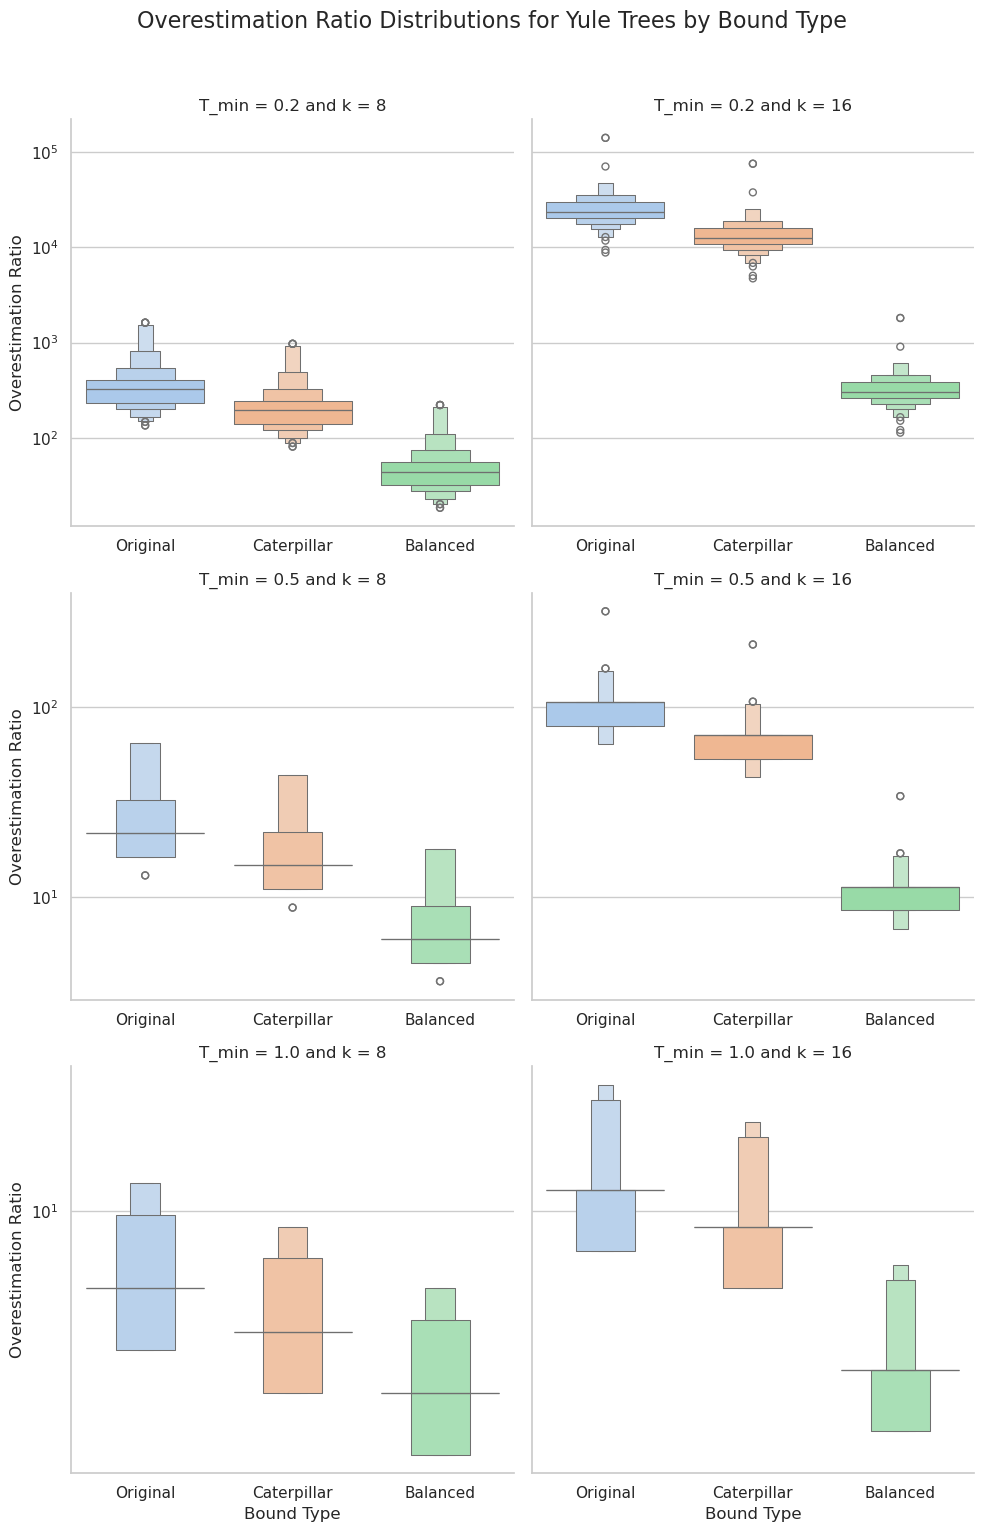

In [35]:
with sns.color_palette('pastel'):
    g = sns.catplot(data=result, kind='boxen',
                x='bound_name',
                y='overestimation_ratio', 
                col='k', 
                row='T_min',
                hue='bound_name',
                k_depth=4,
                legend=False,
                sharey='row',
                sharex=False)
    
    g.set(yscale='log')
    
    # Change axis labels
    g.set_axis_labels("Bound Type", "Overestimation Ratio")
    
    # Change the overall title
    g.fig.suptitle("Overestimation Ratio Distributions for Yule Trees by Bound Type", y=1.02, fontsize=16)
    
    # Optionally: Change individual facet titles
    g.set_titles("T_min = {row_name} and k = {col_name}")
    
    g.despine()
    
    # Optionally: Adjust layout to prevent title overlap
    plt.tight_layout()

    savepath = figures_dir / 'overestimation_ratios' / 'yule_trees_overestimation'
    plt.savefig(savepath, bbox_inches='tight')

## Distribution of $S_k$.

I want to try to understand the distribution of $S_k = \sum_{i=2}^k \tau_i$ where $\tau_i \sim Exp\left({i \choose 2}\right)$ are independent. Here I sample from $S_k$ and plot a KDE plot of its approximate distribution. We also make a CDF plot, and the relevant $-\log(1-CDF)$ that occurs in denominator of all our bounds.

In [68]:
# parameters
k = 200
n_samples = 100000
T_min = 0.01
T_max = 4

In [34]:
# simulate S_k
samples = []
for _ in range(n_samples):
    taus = [np.random.exponential(1 / ((i * (i - 1)) / 2)) for i in range(2, k + 1)]
    samples.append(sum(taus))
samples = np.array(samples)

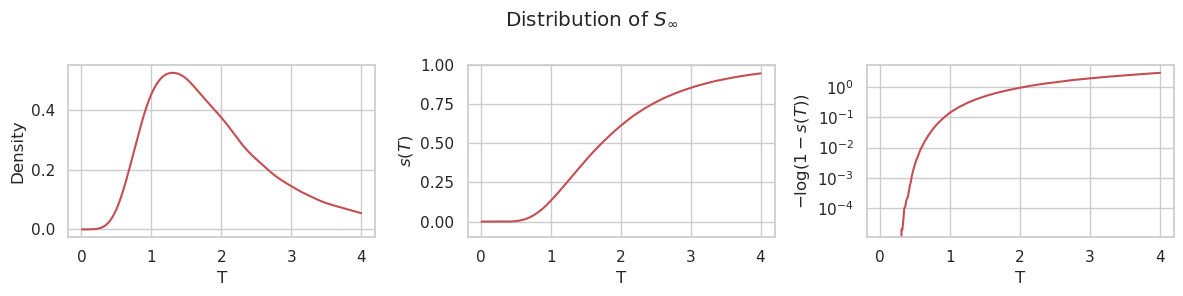

In [69]:
# grid for plotting
T_vals = np.linspace(T_min, T_max, 300)

# Gaussian KDE implementation
def kde_gaussian(x, data, bandwidth):
    return np.mean(
        np.exp(-0.5 * ((x - data) / bandwidth) ** 2)
        / (np.sqrt(2 * np.pi) * bandwidth)
    )

# bandwidth via Silverman's rule of thumb
bandwidth = 1.06 * samples.std() * n_samples ** (-1 / 5)
kde_vals = np.array([kde_gaussian(x, samples, bandwidth) for x in T_vals])

# Calculate CDF Values
ecdf = ECDF(samples)
cdf_values = ecdf(T_vals)

# Make Plots
fig, axs = plt.subplots(1,3, figsize=(12,3))
axs = axs.ravel()

# pdf
ax = axs[0]
sns.lineplot(x=T_vals, y=kde_vals, ax=ax, color='r')
ax.set_xlabel("T")
ax.set_ylabel("Density")

# cdf
ax = axs[1]
sns.lineplot(x=T_vals, y=cdf_values, ax=ax, color='r')
ax.set_xlabel("T")
ax.set_ylabel("$s(T)$")
ax.set_ylim([-0.1,1])

# log(1-cdf)
ax = axs[2]
sns.lineplot(x=T_vals, y=-np.log(1-cdf_values), ax=ax, color='r')
ax.set_xlabel("T")
ax.set_ylabel(f"$-\log(1-s(T))$")
ax.set_yscale('log') 


plt.suptitle('Distribution of $S_\infty$')
plt.tight_layout()
plt.show()

We also showed that our balanced bound only improves things by a constant factor, but I guess I am wondering how large this constant factor is. We saw for our one-step/balanced bound that we can at least say they are of the order:

$$-\log(1-g_{2M, 1}(T)), \qquad M(T) = \frac{1}{1-exp\left(T/2\right)}$$

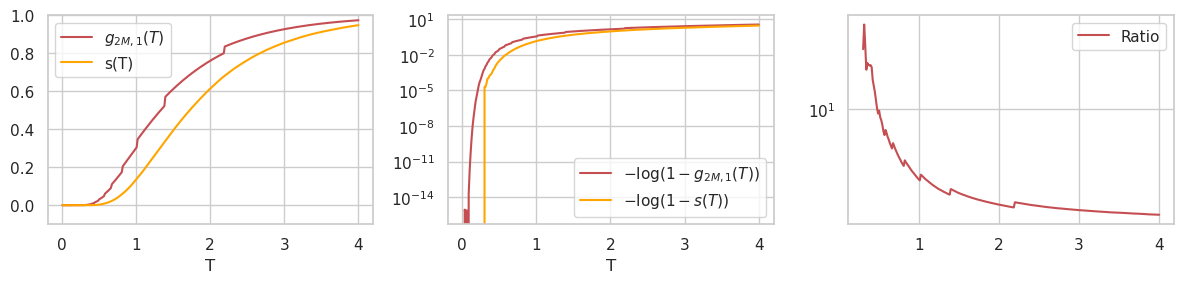

In [87]:
M_func = lambda T: 1 / (1-np.exp(-T/2))
i_vals = np.ceil(2 * M_func(T_vals)).astype(np.int64)

one_step_vals = np.asarray([g_ij(i, 1, T) for i, T in zip(i_vals, T_vals)])

# Make Plots
fig, axs = plt.subplots(1,3, figsize=(12,3))
axs = axs.ravel()

# cdf
ax = axs[0]
sns.lineplot(x=T_vals, y=one_step_vals, ax=ax, color='r', label='$g_{{2M, 1}}(T)$')
sns.lineplot(x=T_vals, y=cdf_values, ax=ax, color='orange', label='s(T)')
ax.set_xlabel("T")
ax.set_ylim([-0.1,1])

# log(1-cdf)
ax = axs[1]
sns.lineplot(x=T_vals, y=-np.log(1-one_step_vals), ax=ax, color='r', label='$-\log(1-g_{{2M, 1}}(T))$')
sns.lineplot(x=T_vals, y=-np.log(1-cdf_values), ax=ax, color='orange', label='$-\log(1-s(T))$')
ax.set_xlabel("T")
ax.set_yscale('log') 

# Ratio
ax = axs[2]
sns.lineplot(x=T_vals, y=np.log(1-one_step_vals)/np.log(1-cdf_values), 
             color='r', ax=ax,
             label='Ratio')
ax.set_yscale('log') 

plt.tight_layout()
plt.show()